<a href="https://colab.research.google.com/github/mariangelesalomar-sudo/eigenfaces-dma-grupo-1/blob/main/eigenfaces_caras_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reconocimiento facial con Eigenfaces (PCA)

**Maestría en Ciencia de Datos — Data Mining Avanzado — 2026 / 2° Cuatrimestre**

Trabajo grupal: detección y comparación de las caras de 14 alumnos de la clase usando
el método clásico de **Eigenfaces** (Análisis de Componentes Principales).

## Pipeline
1. Carga de fotos desde Google Drive (formatos `.jpg`, `.jpeg`, `.png`, `.heic`)
2. Detección de rostros con **DeepFace (RetinaFace)**, con respaldo en Haar Cascade
3. Recorte por borde oval del rostro y conversión a escala de grises de 30×30 px
4. Reducción de dimensionalidad con PCA → Eigenfaces
5. Cálculo del vector promedio por alumno
6. Matriz de distancias euclidianas entre alumnos
7. Ranking de pares más parecidos / menos parecidos

## Notas importantes
- Las fotos **no** se incluyen en este repositorio por privacidad. Cada integrante del grupo
  debe tener acceso a la carpeta compartida de Google Drive.
- El notebook está pensado para correr en **Google Colab**.


## **Paso previo** : Definicion de tamano de cara que correra cada integrante para probar como funciona la red neuronal

In [1]:
# Montar Drive primero, antes de definir rutas
from google.colab import drive
drive.mount('/content/drive')


TAMANO = 30   # ← CADA INTEGRANTE CAMBIA SOLO ESTE NÚMERO
              #   Integrante 1: 30 Mariangeles
              #   Integrante 2: 50 Judith
              #   Integrante 3: 80 Juani
              #   Integrante 4: 100 Fede

# Todo lo demás se calcula solo
DIMENSIONES   = TAMANO * TAMANO
NOMBRE_CONFIG = f"{TAMANO}x{TAMANO}"

RUTA_BASE       = '/content/drive/MyDrive/DMA'
ruta_datos      = f'{RUTA_BASE}/datos_{NOMBRE_CONFIG}'
ruta_checkpoint = f'{ruta_datos}/checkpoint.npz'

import os
os.makedirs(ruta_datos, exist_ok=True)

print("=" * 45)
print(f"⚙️  CONFIGURACIÓN ACTIVA")
print("=" * 45)
print(f"   Tamaño:      {TAMANO}×{TAMANO} píxeles")
print(f"   Dimensiones: {DIMENSIONES:,} por cara")
print(f"   Carpeta:     datos_{NOMBRE_CONFIG}/")


Mounted at /content/drive
⚙️  CONFIGURACIÓN ACTIVA
   Tamaño:      30×30 píxeles
   Dimensiones: 900 por cara
   Carpeta:     datos_30x30/


## 1. Instalar librerías externas





In [2]:
# opencv-python-headless → detectar y recortar caras
# scikit-learn           → hacer PCA (Eigenfaces)
# pillow-heif            → leer fotos .HEIC de iPhone
# matplotlib             → hacer gráficos
# scipy                  → calcular distancias entre vectores

!pip install opencv-python-headless scikit-learn pillow-heif matplotlib scipy Pillow --quiet

print("✅ Librerías instaladas correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 47.2 MB/s eta 0:00:00
✅ Librerías instaladas correctamente


## 2. Importar librerías al entorno de trabajo

In [3]:
import os                          # para leer archivos del disco
import cv2                         # para procesar imágenes y detectar caras
import numpy as np                 # para trabajar con vectores y matrices
import matplotlib.pyplot as plt    # para hacer gráficos y mostrar imágenes
from PIL import Image              # para abrir imágenes (incluyendo HEIC)
from sklearn.decomposition import PCA      # para hacer Eigenfaces
from scipy.spatial.distance import euclidean  # para calcular distancias
from google.colab import drive     # para conectarse a Google Drive

# Activar soporte para fotos .HEIC (formato iPhone)
from pillow_heif import register_heif_opener
register_heif_opener()

import warnings
warnings.filterwarnings('ignore')  # silenciar advertencias menores

print("✅ Todo importado. Estamos listos para trabajar.")

✅ Todo importado. Estamos listos para trabajar.


## 3. Conectar a Google Drive

In [4]:
ruta_fotos = '/content/drive/MyDrive/caras'

archivos_totales = os.listdir(ruta_fotos)

print(f"Drive conectado correctamente")
print(f"Carpeta: {ruta_fotos}")
print(f"Cantidad total de archivos en la carpeta: {len(archivos_totales)}")

Drive conectado correctamente
Carpeta: /content/drive/MyDrive/caras
Cantidad total de archivos en la carpeta: 2083


## 4. Definir a qué alumno pertenece cada foto

In [5]:
# PROBLEMA: todas las fotos están en una sola carpeta,
# y el nombre del alumno está dentro del nombre del archivo.
# Además, el mismo alumno aparece escrito de formas distintas
# (typos, mayúsculas, guiones extra, etc.)

MAPA_NOMBRES = {
    # Juani (4 variantes)
    'juani_cahionne'    : 'juani_cacchione',
    'juani_cachionne'   : 'juani_cacchione',
    'juani_cachione'    : 'juani_cacchione',
    'juani_cacchione'   : 'juani_cacchione',
    'juan_cacchione'    : 'juani_cacchione',
    # Juani P (2 variantes)
    'juani_paberolis'   : 'juani_paberolis',
    'ignacio_paberolis' : 'juani_paberolis',

    # Mariángeles (2 variantes)
    'mariangeles_alomar': 'mariangeles_alomar',
    'mariangeles_aloar' : 'mariangeles_alomar',
    # Miguel (2 variantes)
    'miguel_garrone'    : 'miguel_garrone',
    'migue_garrone'     : 'miguel_garrone',
    # El resto (sin variantes)
    'agustina_sebben'   : 'agustina_sebben',
    'belen_maldonado'   : 'belen_maldonado',
    'fede_spinelli'     : 'fede_spinelli',
    'guillermo_anso'    : 'guillermo_anso',
    'judi_luna'         : 'judi_luna',
    'judi_luna_'        : 'judi_luna',

    'lucia_tamplin'     : 'lucia_tamplin',
    'Lucia_Tamplin'     : 'lucia_tamplin',
    'martin_ceriotti'   : 'martin_ceriotti',
    'matias_villanueva' : 'matias_villanueva',
    'millie_teran'      : 'millie_teran',
    'tomas_delbo'       : 'tomas_delbo',
}

def extraer_nombre_alumno(nombre_archivo):
    """Dado el nombre de un archivo, devuelve el nombre canónico del alumno."""
    sin_extension = os.path.splitext(nombre_archivo)[0]
    # Recorremos los prefijos del más largo al más corto
    prefijos = sorted(MAPA_NOMBRES.keys(), key=len, reverse=True)
    for prefijo in prefijos:
        if sin_extension.startswith(prefijo):
            return MAPA_NOMBRES[prefijo]
    return None  # archivo no reconocido

# ── Prueba visual ──────────────────────────────────────────
print("Probando la función con algunos ejemplos:\n")
ejemplos = [
    'martin_ceriotti (5).jpg',
    'belen_maldonado_001.heic',
    'juani_cahionne (3).jpeg',
    'juani_cacchione (1).heic',
    'migue_garrone (1).MOV',
    'Lucia_Tamplin_03.jpeg',
    'judi_luna_ (2).jpg',
]
for e in ejemplos:
    resultado = extraer_nombre_alumno(e)
    print(f"   '{e}'  →  '{resultado}'")

print("\nLa función reconoce correctamente los nombres")

Probando la función con algunos ejemplos:

   'martin_ceriotti (5).jpg'  →  'martin_ceriotti'
   'belen_maldonado_001.heic'  →  'belen_maldonado'
   'juani_cahionne (3).jpeg'  →  'juani_cacchione'
   'juani_cacchione (1).heic'  →  'juani_cacchione'
   'migue_garrone (1).MOV'  →  'miguel_garrone'
   'Lucia_Tamplin_03.jpeg'  →  'lucia_tamplin'
   'judi_luna_ (2).jpg'  →  'judi_luna'

La función reconoce correctamente los nombres


4.1 Control de nombres mapeados

In [6]:
# ── Verificación automática: ninguna foto sin mapear ────────
extensiones = ('.jpg', '.jpeg', '.png', '.heic')
no_reconocidos = []
reconocidos    = {}

for archivo in sorted(os.listdir(ruta_fotos)):
    ext = os.path.splitext(archivo)[1].lower()
    if ext not in extensiones:
        continue
    alumno = extraer_nombre_alumno(archivo)
    if alumno is None:
        no_reconocidos.append(archivo)
    else:
        reconocidos[alumno] = reconocidos.get(alumno, 0) + 1

print(f"\n📊 COBERTURA DEL MAPA DE NOMBRES")
print(f"{'='*50}")
print(f"   ✅ Fotos reconocidas:  {sum(reconocidos.values())}")
print(f"   ❌ No reconocidas:     {len(no_reconocidos)}")

print(f"\n   Fotos por alumno:")
for alumno, cantidad in sorted(reconocidos.items()):
    print(f"   {alumno:25s}: {cantidad:4d} fotos")

if no_reconocidos:
    print(f"\n⚠️  ATENCIÓN — estos archivos NO van a procesarse:")
    for f in no_reconocidos:
        print(f"   {f}")
    print(f"\n   → Agregá los prefijos faltantes al MAPA_NOMBRES y volvé a correr esta celda.")
else:
    print(f"\n✅ Todas las fotos están mapeadas. Podés continuar con la Celda 5.")


📊 COBERTURA DEL MAPA DE NOMBRES
   ✅ Fotos reconocidas:  2083
   ❌ No reconocidas:     0

   Fotos por alumno:
   agustina_sebben          :  109 fotos
   belen_maldonado          :  111 fotos
   fede_spinelli            :  123 fotos
   guillermo_anso           :  155 fotos
   juani_cacchione          :  138 fotos
   juani_paberolis          :   92 fotos
   judi_luna                :  233 fotos
   lucia_tamplin            :  136 fotos
   mariangeles_alomar       :  137 fotos
   martin_ceriotti          :  178 fotos
   matias_villanueva        :  175 fotos
   miguel_garrone           :  157 fotos
   millie_teran             :  207 fotos
   tomas_delbo              :  132 fotos

✅ Todas las fotos están mapeadas. Podés continuar con la Celda 5.


## 5. Abrir y mostrar UNA foto original

Foto original de martin_ceriotti: 'martin_ceriotti (1).jpeg'
   Dimensiones: 3213 px de ancho × 5712 px de alto
   Canales de color: 3 (R, G, B)


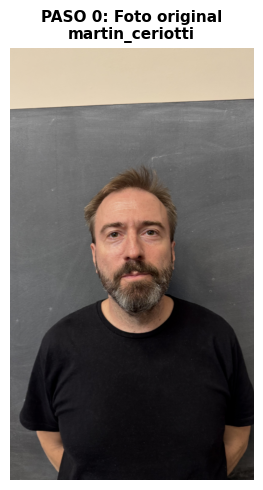

In [7]:
# Antes de procesar todo, vamos a ver cómo se ve una foto
# tal cual sale de la cámara, sin ninguna modificación.

alumno_ejemplo = 'martin_ceriotti'

foto_ejemplo = None
for archivo in sorted(os.listdir(ruta_fotos)):
    if extraer_nombre_alumno(archivo) == alumno_ejemplo:
        ext = os.path.splitext(archivo)[1].lower()
        if ext in ('.jpg', '.jpeg', '.png', '.heic'):
            foto_ejemplo = archivo
            break

ruta_ejemplo = os.path.join(ruta_fotos, foto_ejemplo)

# Leer la imagen (soporte para HEIC y formatos comunes)
def leer_imagen(ruta):
    ext = os.path.splitext(ruta)[1].lower()
    if ext == '.heic':
        img_pil = Image.open(ruta).convert('RGB')
        return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    else:
        return cv2.imread(ruta)

imagen_original = leer_imagen(ruta_ejemplo)
imagen_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

print(f"Foto original de {alumno_ejemplo}: '{foto_ejemplo}'")
print(f"   Dimensiones: {imagen_original.shape[1]} px de ancho × {imagen_original.shape[0]} px de alto")
print(f"   Canales de color: {imagen_original.shape[2]} (R, G, B)")

plt.figure(figsize=(4, 5))
plt.imshow(imagen_rgb)
plt.title(f"PASO 0: Foto original\n{alumno_ejemplo}", fontsize=11, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Recorte por borde real del rostro con DeepFace

In [8]:
# DeepFace detecta la cara Y sus landmarks (puntos clave).
# Con esos puntos podemos dibujar una MÁSCARA ELÍPTICA que sigue el óvalo
# de la cara y recortar SOLO lo que está dentro del óvalo (fondo negro afuera).

!pip install deepface --quiet
print("✅ DeepFace instalado")

import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace

print("✅ DeepFace importado\n")


def recortar_cara_por_borde(imagen_bgr, margen=0.18):
    """
    Detecta la cara con DeepFace y recorta siguiendo el borde
    real del rostro (forma elíptica), no un rectángulo rígido.
    """
    alto, ancho = imagen_bgr.shape[:2]
    imagen_rgb  = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

    try:
        caras = DeepFace.extract_faces(
            img_path          = imagen_bgr,
            detector_backend  = 'opencv',
            enforce_detection = False,
            align             = True
        )

        caras_validas = [c for c in caras if c['confidence'] > 0]
        if not caras_validas:
            return None, None, None

        mejor     = max(caras_validas, key=lambda c: c['confidence'])
        confianza = mejor['confidence']

        region = mejor['facial_area']
        x, y   = region['x'], region['y']
        w, h   = region['w'], region['h']

        landmarks = region
        ojo_izq   = landmarks.get('left_eye')
        ojo_der   = landmarks.get('right_eye')
        nariz     = landmarks.get('nose')
        boca_izq  = landmarks.get('mouth_left')
        boca_der  = landmarks.get('mouth_right')

        # Centro: punto medio entre los dos ojos
        if ojo_izq and ojo_der:
            cx = int((ojo_izq[0] + ojo_der[0]) / 2)
            cy = int((ojo_izq[1] + ojo_der[1]) / 2)
        else:
            cx = x + w // 2
            cy = y + h // 2

        # Eje horizontal: distancia entre ojos × factor de margen
        if ojo_izq and ojo_der:
            dist_ojos  = np.sqrt((ojo_der[0]-ojo_izq[0])**2 +
                                 (ojo_der[1]-ojo_izq[1])**2)
            radio_x    = int(dist_ojos * 1.5 * (1 + margen))
        else:
            radio_x    = int(w * 0.55 * (1 + margen))

        # Eje vertical
        if ojo_izq and ojo_der and boca_izq and boca_der:
            cy_boca    = int((boca_izq[1] + boca_der[1]) / 2)
            dist_ojo_boca = abs(cy_boca - cy)
            radio_y_abajo  = int(dist_ojo_boca * 1.3 * (1 + margen))
            radio_y_arriba = int(dist_ojo_boca * 1.6 * (1 + margen))
        else:
            radio_y_abajo  = int(h * 0.55 * (1 + margen))
            radio_y_arriba = int(h * 0.55 * (1 + margen))

        # Ángulo de inclinación de la cara
        if ojo_izq and ojo_der:
            angulo = np.degrees(np.arctan2(
                ojo_der[1] - ojo_izq[1],
                ojo_der[0] - ojo_izq[0]
            ))
        else:
            angulo = 0

        # Recorte rectangular amplio (zona de trabajo)
        margen_rect = int(max(radio_x, radio_y_abajo, radio_y_arriba) * 1.1)
        rx1 = max(0,     cx - margen_rect)
        ry1 = max(0,     cy - margen_rect)
        rx2 = min(ancho, cx + margen_rect)
        ry2 = min(alto,  cy + margen_rect)

        recorte_rgb = imagen_rgb[ry1:ry2, rx1:rx2].copy()
        rh, rw      = recorte_rgb.shape[:2]

        cx_local = cx - rx1
        cy_local = cy - ry1

        radio_y_prom = (radio_y_arriba + radio_y_abajo) // 2

        mascara = np.zeros((rh, rw), dtype=np.uint8)
        cv2.ellipse(
            mascara,
            center    = (cx_local, cy_local),
            axes      = (radio_x, radio_y_prom),
            angle     = angulo,
            startAngle= 0,
            endAngle  = 360,
            color     = 255,
            thickness = -1
        )

        mascara_suave = cv2.GaussianBlur(mascara, (21, 21), 0)
        mascara_3ch = np.stack([mascara_suave]*3, axis=-1).astype(np.float32) / 255.0
        cara_con_mascara = (recorte_rgb.astype(np.float32) * mascara_3ch).astype(np.uint8)

        ys, xs = np.where(mascara > 0)
        if len(xs) == 0 or len(ys) == 0:
            return None, None, None

        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        cara_recortada = cara_con_mascara[y_min:y_max, x_min:x_max]

        cara_gris       = cv2.cvtColor(cara_recortada, cv2.COLOR_RGB2GRAY)
        cara_gris_tamano = cv2.resize(cara_gris, (TAMANO, TAMANO))

        return cara_gris_tamano, cara_recortada, confianza

    except Exception as e:
        return None, None, None


# Haar como respaldo
clasificador_haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.5 MB/s eta 0:00:00
✅ DeepFace instalado
26-05-04 14:48:37 - Directory /root/.deepface has been created
26-05-04 14:48:37 - Directory /root/.deepface/weights has been created
✅ DeepFace importado



## 7. Procesar TODAS las fotos (con checkpoint)

In [9]:
## 7. Procesar TODAS las fotos (con checkpoint)

# MEJORAS clave:
#   1. BARRA DE PROGRESO
#   2. SIN DEDUPLICACIÓN: se procesan TODAS las fotos aunque tengan el mismo nombre base
#   3. GUARDADO PARCIAL cada 50 fotos (checkpoint en Drive)
#   4. RETOMAR DESDE CHECKPOINT si Colab se reinicia — nunca se pierde trabajo
#   5. DeepFace + Haar como respaldo

import numpy as np
import os
import cv2
import time
from PIL import Image

EXTENSIONES     = ('.jpg', '.jpeg', '.png', '.heic')
GUARDAR_CADA    = 50
ruta_checkpoint = f'{ruta_datos}/checkpoint.npz'

def leer_imagen(ruta):
    ext = os.path.splitext(ruta)[1].lower()
    if ext == '.heic':
        try:
            img_pil = Image.open(ruta).convert('RGB')
            return cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
        except:
            return None
    else:
        return cv2.imread(ruta)

clasificador_haar = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# ── Construir lista de archivos a procesar ──────────────────
# Sin deduplicación: se toman TODAS las imágenes reconocidas
print("📋 Analizando archivos disponibles...\n")

archivos_todos      = sorted(os.listdir(ruta_fotos))
archivos_a_procesar = []

for archivo in archivos_todos:
    ext = os.path.splitext(archivo)[1].lower()
    if ext not in EXTENSIONES:
        continue
    alumno = extraer_nombre_alumno(archivo)
    if alumno is None:
        continue
    archivos_a_procesar.append(archivo)

archivos_a_procesar = sorted(archivos_a_procesar)
print(f"   Total de fotos a procesar: {len(archivos_a_procesar)}")

# ── Inicializar variables ────────────────────────────────────
todos_vectores         = []
todas_etiquetas        = []
todas_imagenes         = []
imagen_repr            = {}
ruta_repr              = {}
conteo                 = {}
archivos_ya_procesados = set()

os.makedirs(os.path.dirname(ruta_checkpoint), exist_ok=True)

# ── Retomar desde checkpoint si existe ───────────────────────
if os.path.exists(ruta_checkpoint):
    print(f"\n♻️  Checkpoint encontrado. Retomando desde donde quedó...")
    cp = np.load(ruta_checkpoint, allow_pickle=True)
    todos_vectores         = list(cp['vectores'])
    todas_etiquetas        = list(cp['etiquetas'])
    archivos_ya_procesados = set(cp['archivos_procesados'])

    for v, e in zip(todos_vectores, todas_etiquetas):
        conteo[e] = conteo.get(e, 0) + 1
        if e not in imagen_repr:
            imagen_repr[e] = v.reshape(TAMANO, TAMANO).astype(np.uint8)

    todas_imagenes = [v.reshape(TAMANO, TAMANO).astype(np.uint8)
                      for v in todos_vectores]

    print(f"   ✅ {len(todos_vectores)} fotos recuperadas")
    print(f"   ⏭️  Se saltean {len(archivos_ya_procesados)} archivos ya procesados\n")
else:
    print(f"\n🆕 No hay checkpoint previo. Empezando desde cero.\n")

# ── Procesar solo los pendientes ─────────────────────────────
archivos_pendientes = [a for a in archivos_a_procesar
                       if a not in archivos_ya_procesados]

total       = len(archivos_pendientes)
sin_cara    = 0
errores     = 0
uso_haar    = 0
inicio      = time.time()

print(f"🔍 Procesando {total} archivos pendientes...\n")

for i, archivo in enumerate(archivos_pendientes):
    if i % 10 == 0 or i == total - 1:
        pct      = (i + 1) / total
        barras   = int(pct * 30)
        barra    = "█" * barras + "░" * (30 - barras)
        elapsed  = time.time() - inicio
        restante = (elapsed / (i + 1)) * (total - i - 1) if i > 0 else 0
        print(f"\r   [{barra}] {i+1}/{total}  "
              f"({pct*100:.0f}%)  ~{restante/60:.1f} min restantes",
              end='', flush=True)

    alumno = extraer_nombre_alumno(archivo)
    ruta   = os.path.join(ruta_fotos, archivo)
    imagen = leer_imagen(ruta)
    if imagen is None:
        errores += 1
        archivos_ya_procesados.add(archivo)
        continue

    cara_tamano, _, _ = recortar_cara_por_borde(imagen)

    if cara_tamano is None:
        gris  = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
        caras = clasificador_haar.detectMultiScale(
            gris, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40)
        )
        if len(caras) > 0:
            x, y, w, h = sorted(caras, key=lambda c: c[2]*c[3], reverse=True)[0]
            cara_tamano = cv2.resize(gris[y:y+h, x:x+w], (TAMANO, TAMANO))
            uso_haar   += 1
        else:
            sin_cara += 1
            archivos_ya_procesados.add(archivo)
            continue

    vector = cara_tamano.flatten().astype(float)
    todos_vectores.append(vector)
    todas_etiquetas.append(alumno)
    todas_imagenes.append(cara_tamano)
    conteo[alumno] = conteo.get(alumno, 0) + 1
    archivos_ya_procesados.add(archivo)

    if alumno not in imagen_repr:
        imagen_repr[alumno] = cara_tamano
        ruta_repr[alumno]   = ruta

    if len(todos_vectores) % GUARDAR_CADA == 0:
        np.savez_compressed(
            ruta_checkpoint,
            vectores            = np.array(todos_vectores),
            etiquetas           = np.array(todas_etiquetas),
            archivos_procesados = np.array(list(archivos_ya_procesados))
        )

np.savez_compressed(
    ruta_checkpoint,
    vectores            = np.array(todos_vectores),
    etiquetas           = np.array(todas_etiquetas),
    archivos_procesados = np.array(list(archivos_ya_procesados))
)

matriz_vectores = np.array(todos_vectores)
etiquetas       = np.array(todas_etiquetas)
nombres_alumnos = sorted(conteo.keys())

print(f"\n\n📊 RESUMEN: {len(todos_vectores)} fotos procesadas")
print(f"   Sin cara: {sin_cara}  |  Errores: {errores}  |  Haar respaldo: {uso_haar}")

📋 Analizando archivos disponibles...

   Total de fotos a procesar: 2083

♻️  Checkpoint encontrado. Retomando desde donde quedó...
   ✅ 2022 fotos recuperadas
   ⏭️  Se saltean 2083 archivos ya procesados

🔍 Procesando 0 archivos pendientes...



📊 RESUMEN: 2022 fotos procesadas
   Sin cara: 0  |  Errores: 0  |  Haar respaldo: 0


## 8. PCA — Eigenfaces

In [10]:
# Reducimos las dimensiones a eigenfaces (componentes principales).

N_EIGENFACES = 80 # todos los integrantes usan 80 eigenfaces
n_componentes = min(len(todos_vectores) - 1, N_EIGENFACES)

print(f"Aplicando PCA: {len(todos_vectores)} fotos × {DIMENSIONES:,} dimensiones → {n_componentes} eigenfaces\n")

pca = PCA(n_components=n_componentes, whiten=True)
pca.fit(matriz_vectores)

fotos_proyectadas = pca.transform(matriz_vectores)

varianza = np.cumsum(pca.explained_variance_ratio_) * 100
print(f"✅ Con {n_componentes} eigenfaces capturamos el {varianza[-1]:.1f}% de la información")

# ── Cuántos eigenfaces necesitaría para 90% y 95% de varianza ──
# (útil para comparar en la presentación grupal)
for pct_objetivo in [90, 95]:
    idx = np.argmax(varianza >= pct_objetivo) + 1
    print(f"   Para llegar al {pct_objetivo}% de varianza hacen falta: {idx} eigenfaces")

Aplicando PCA: 2022 fotos × 900 dimensiones → 80 eigenfaces

✅ Con 80 eigenfaces capturamos el 92.4% de la información
   Para llegar al 90% de varianza hacen falta: 52 eigenfaces
   Para llegar al 95% de varianza hacen falta: 1 eigenfaces


# 8.b Cara Promedio

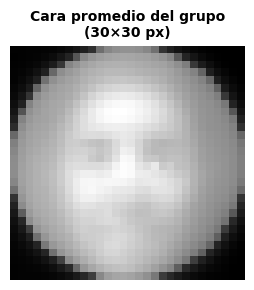

📊 Guardado: cara_promedio.png


In [11]:
# ── CELDA 8b: Cara promedio ──────────────────────────────────
# La "cara promedio" es el promedio de todos los vectores
# de píxeles ANTES de aplicar PCA.
# Visualmente muestra cómo es la cara "típica" del grupo.

cara_promedio = matriz_vectores.mean(axis=0).reshape(TAMANO, TAMANO)

plt.figure(figsize=(3, 3))
plt.imshow(cara_promedio, cmap='gray', interpolation='nearest')
plt.title(f'Cara promedio del grupo\n({TAMANO}×{TAMANO} px)', fontsize=10, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig(f'{ruta_datos}/cara_promedio.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📊 Guardado: cara_promedio.png")

# **8.c Matriz de Eigenfaces**

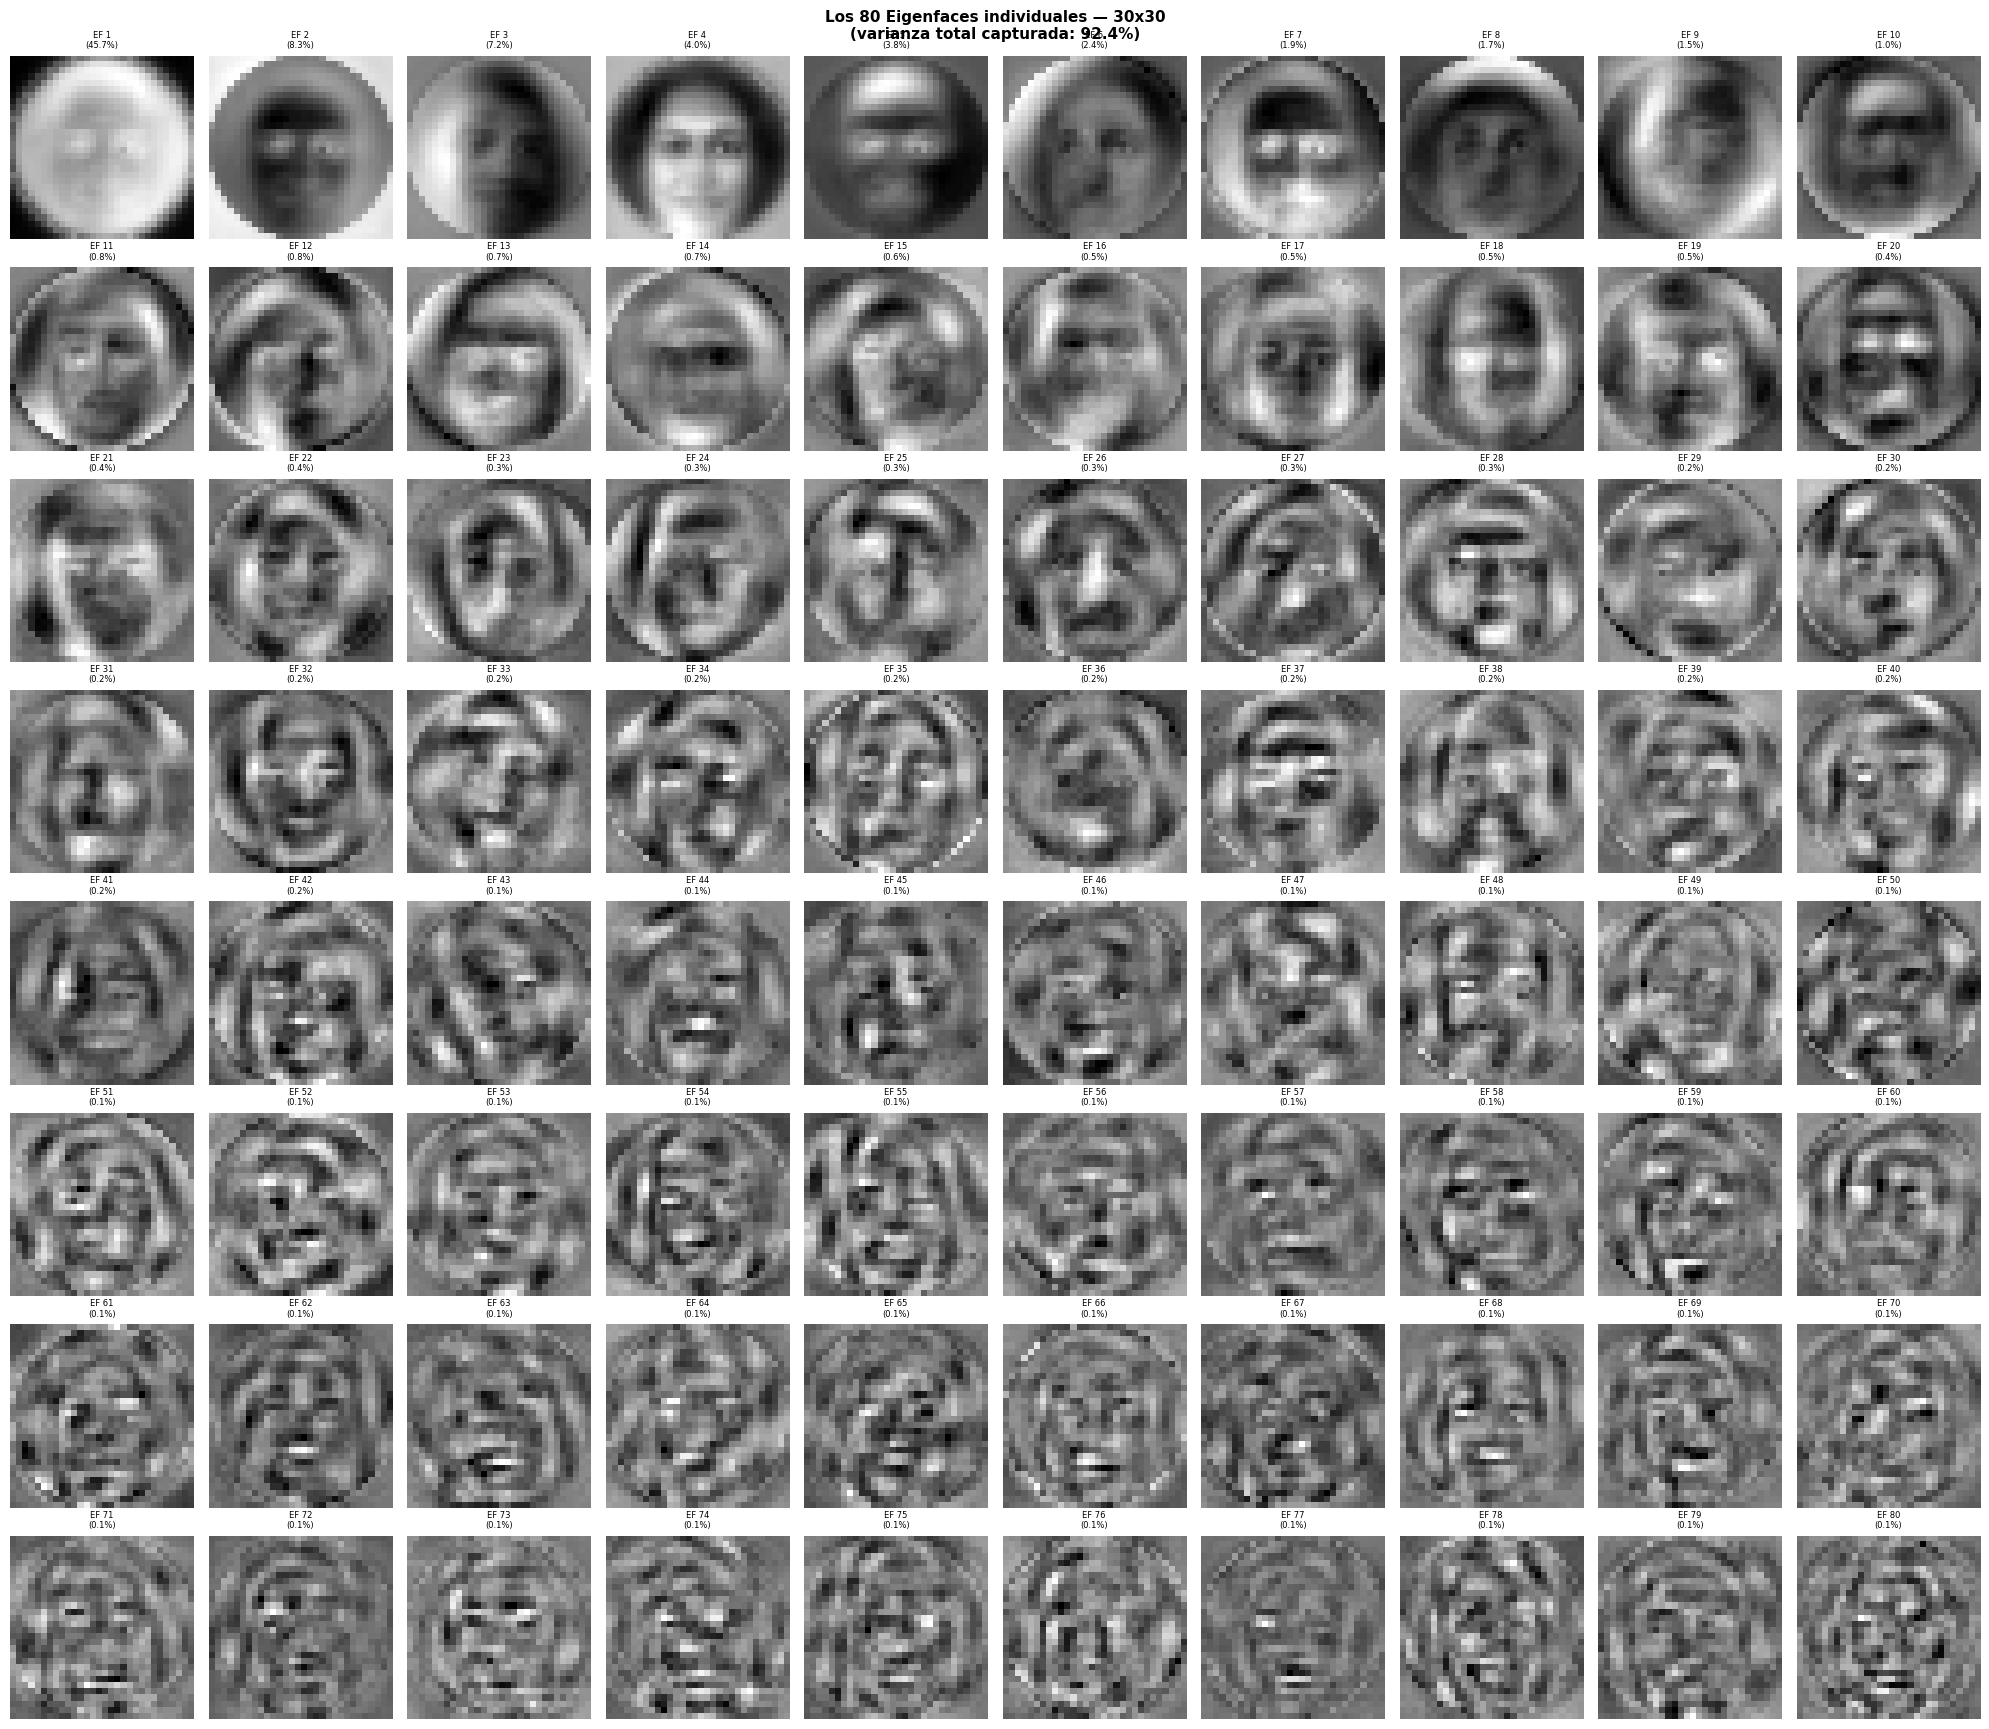

📊 Guardado: eigenfaces_individuales.png


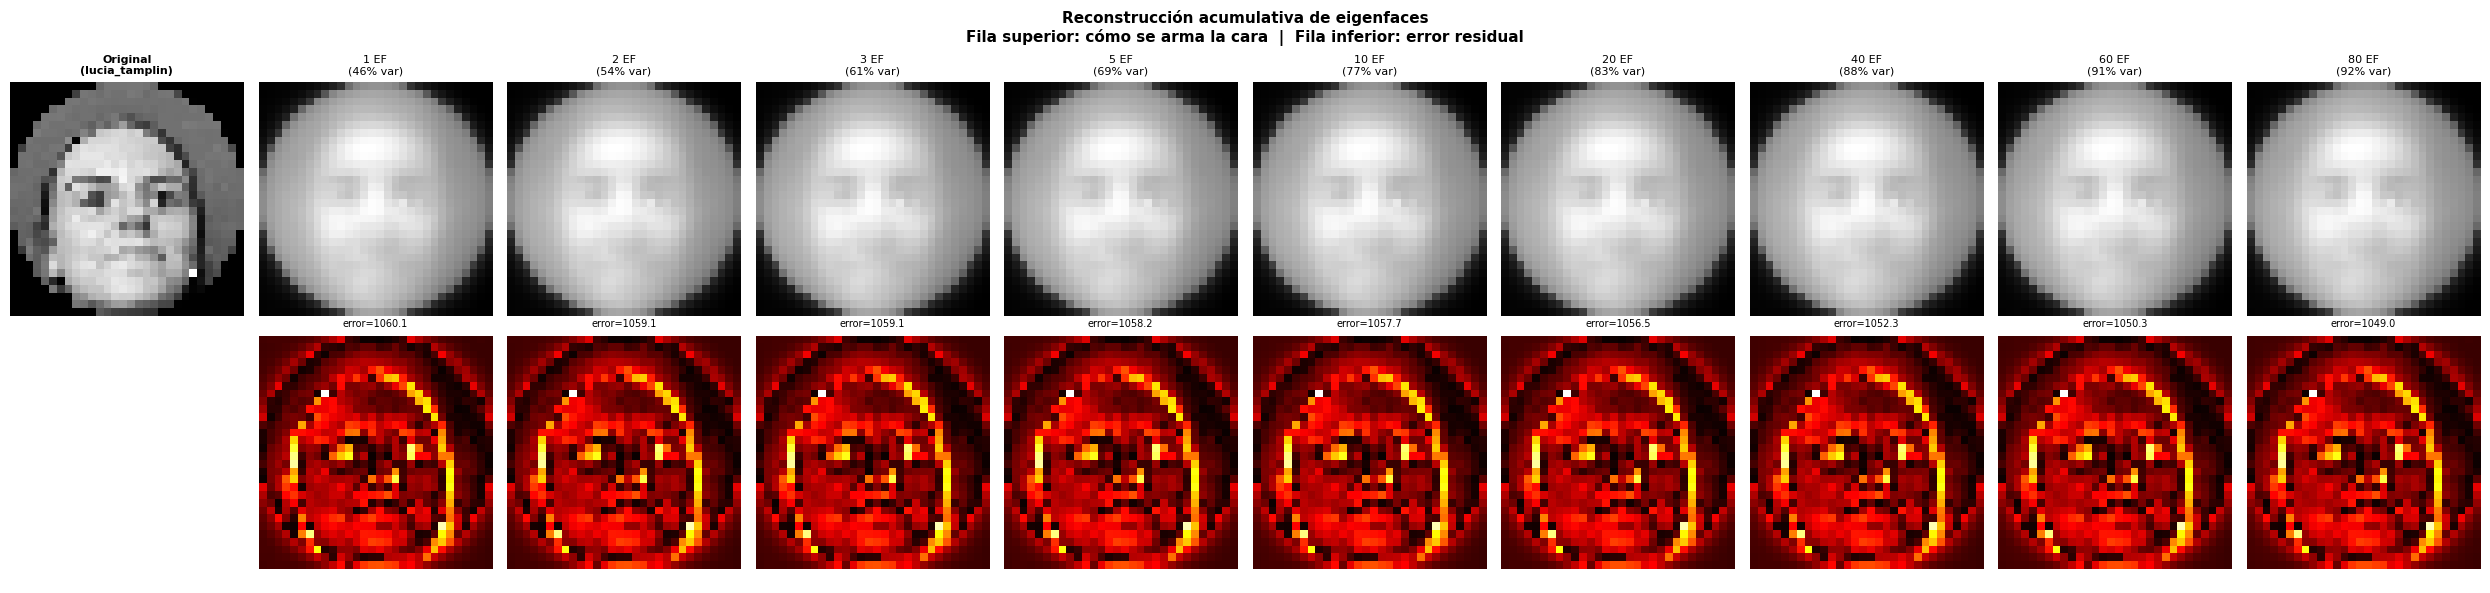

📊 Guardado: reconstruccion_acumulativa.png

💡 Interpretación:
   Con 1 eigenface:  la cara es casi irreconocible
   Con ~10:          empiezan a verse los rasgos principales
   Con ~80:         la reconstrucción es muy cercana al original

   La fila inferior (rojo=error grande) muestra dónde quedan
   los detalles que aún no capturaron los eigenfaces usados.


In [19]:
## 8c. Eigenfaces individuales y reconstrucción acumulativa

from sklearn.decomposition import PCA

# ── Parte 1: Los 80 eigenfaces individuales ───────────────────
n_mostrar = min(80, n_componentes)
cols      = 10
filas     = n_mostrar // cols

fig, axes = plt.subplots(filas, cols, figsize=(cols * 2, filas * 2.2))
axes      = axes.flatten()

for i in range(n_mostrar):
    ef = pca.components_[i].reshape(TAMANO, TAMANO)
    axes[i].imshow(ef, cmap='gray')
    axes[i].set_title(f'EF {i+1}\n({pca.explained_variance_ratio_[i]*100:.1f}%)',
                      fontsize=6)
    axes[i].axis('off')

plt.suptitle(f'Los {n_mostrar} Eigenfaces individuales — {NOMBRE_CONFIG}\n'
             f'(varianza total capturada: {varianza[n_mostrar-1]:.1f}%)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta_datos}/eigenfaces_individuales.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Guardado: eigenfaces_individuales.png")

# ── Parte 2: Reconstrucción acumulativa ───────────────────────
# Tomamos UNA cara representativa y la reconstruimos
# agregando eigenfaces de a uno, para ver cómo se va "armando"
#
# La fórmula es:
#   cara_reconstruida = cara_promedio + coef_1*EF1 + coef_2*EF2 + ...
#
# Donde los coeficientes son las coordenadas de esa cara
# en el espacio de eigenfaces (fotos_proyectadas)

# Elegir la primera foto de cada alumno como ejemplo
# o podés cambiar el índice para ver otra cara
idx_ejemplo = 0   # índice de la foto a reconstruir
cara_original = matriz_vectores[idx_ejemplo]
alumno_ejemplo = todas_etiquetas[idx_ejemplo]

# La cara promedio del grupo (punto de partida de la reconstrucción)
cara_promedio_vec = pca.mean_

# Coordenadas de esta cara en el espacio eigenface
coordenadas = fotos_proyectadas[idx_ejemplo]

# Checkpoints de reconstrucción: con cuántos eigenfaces mostrar
if n_componentes >= 80:
    checkpoints = [1, 2, 3, 5, 10, 20, 40, 60, 80]
else:
    checkpoints = [1, 2, 3, 5, 10, n_componentes//2, n_componentes]
    checkpoints = sorted(set(checkpoints))

n_checks = len(checkpoints)
fig, axes = plt.subplots(2, n_checks + 1, figsize=((n_checks + 1) * 2.5, 6))

# Columna 0: cara original
axes[0, 0].imshow(cara_original.reshape(TAMANO, TAMANO),
                  cmap='gray', interpolation='nearest')
axes[0, 0].set_title(f'Original\n({alumno_ejemplo})', fontsize=8, fontweight='bold')
axes[0, 0].axis('off')
axes[1, 0].axis('off')  # vacío abajo

# Columnas siguientes: reconstrucción acumulativa
for col, n_ef in enumerate(checkpoints, 1):

    # Reconstruir usando los primeros n_ef eigenfaces
    # cara ≈ media + sum(coef_i * EF_i) para i=1..n_ef
    reconstruccion = cara_promedio_vec.copy()
    for k in range(n_ef):
        reconstruccion += coordenadas[k] * pca.components_[k]

    # Fila superior: cara reconstruida
    axes[0, col].imshow(reconstruccion.reshape(TAMANO, TAMANO),
                        cmap='gray', interpolation='nearest')
    varianza_acum_k = varianza[n_ef - 1]
    axes[0, col].set_title(f'{n_ef} EF\n({varianza_acum_k:.0f}% var)',
                            fontsize=8)
    axes[0, col].axis('off')

    # Fila inferior: diferencia con la original (error de reconstrucción)
    diferencia = np.abs(cara_original - reconstruccion)
    axes[1, col].imshow(diferencia.reshape(TAMANO, TAMANO),
                        cmap='hot', interpolation='nearest')
    error = np.mean(diferencia**2)
    axes[1, col].set_title(f'error={error:.1f}', fontsize=7)
    axes[1, col].axis('off')

# Etiquetas de fila
axes[0, 0].set_ylabel('Reconstrucción', fontsize=9, rotation=90, labelpad=5)
axes[1, 0].set_ylabel('Error (diff)', fontsize=9, rotation=90, labelpad=5)

plt.suptitle(f'Reconstrucción acumulativa de eigenfaces\n'
             f'Fila superior: cómo se arma la cara  |  Fila inferior: error residual',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta_datos}/reconstruccion_acumulativa.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Guardado: reconstruccion_acumulativa.png")
print(f"\n💡 Interpretación:")
print(f"   Con 1 eigenface:  la cara es casi irreconocible")
print(f"   Con ~10:          empiezan a verse los rasgos principales")
print(f"   Con ~{checkpoints[-1]}:         la reconstrucción es muy cercana al original")
print(f"\n   La fila inferior (rojo=error grande) muestra dónde quedan")
print(f"   los detalles que aún no capturaron los eigenfaces usados.")

8d. ISOMAP — Reducción de dimensionalidad no lineal

🧮 Aplicando ISOMAP...
   Fotos:       2022
   Dimensiones: 900 → 80 componentes
   Vecinos:     10
   (esto puede tardar varios minutos...)

✅ ISOMAP aplicado en 0.1 minutos
   Dimensiones antes:  (2022, 900)
   Dimensiones después: (2022, 80)


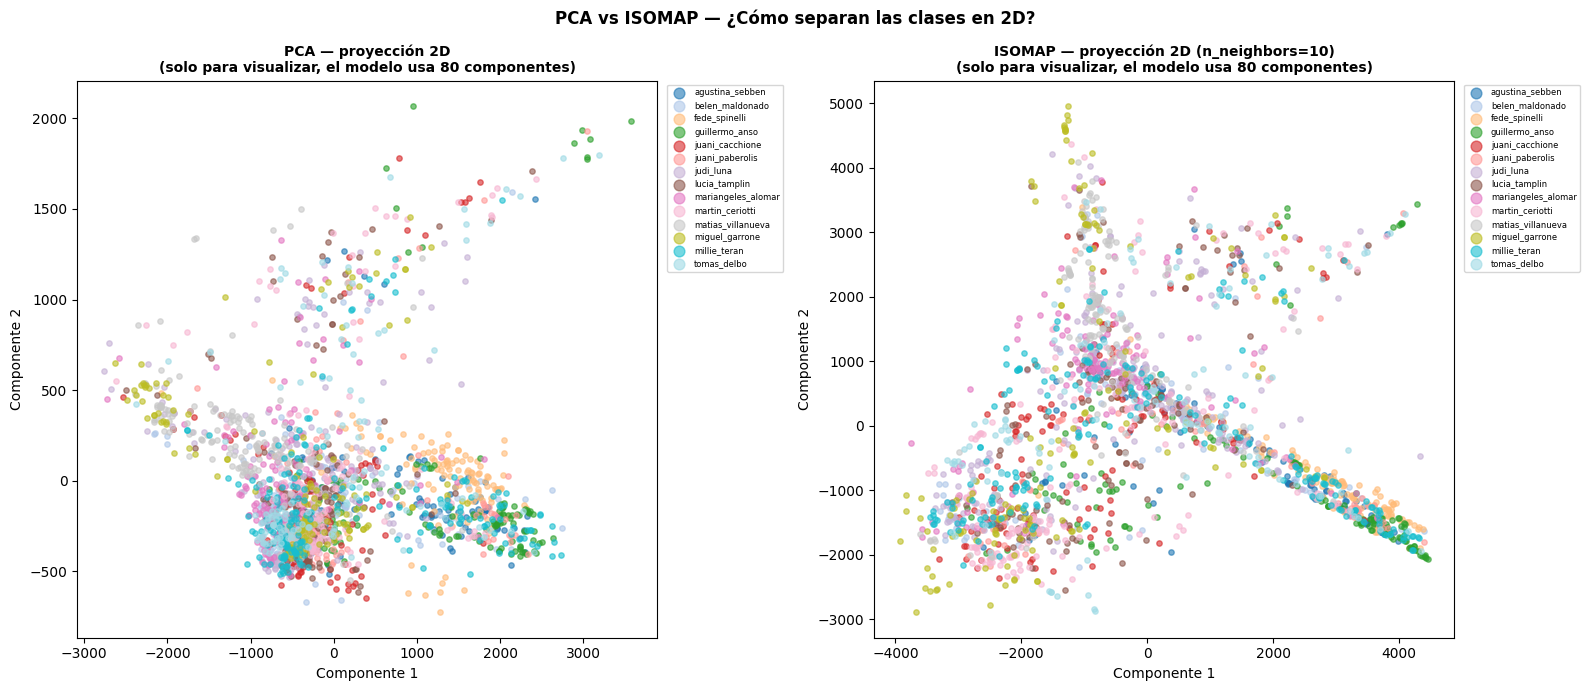

📊 Guardado: pca_vs_isomap_2d.png

💡 Interpretación:
   Si los grupos están más separados en ISOMAP → ISOMAP captura mejor la estructura
   Si son similares → PCA es suficiente y más rápido


In [20]:
## 8d. ISOMAP — Reducción de dimensionalidad no lineal

# ISOMAP es una alternativa no lineal al PCA.
# Mientras PCA busca direcciones de máxima varianza (asume estructura lineal),
# ISOMAP asume que los datos viven en una variedad curva y trata de
# "desenrollarla" para encontrar la geometría real de los datos.
#
# Para caras con distintos ángulos e iluminaciones, ISOMAP puede
# capturar mejor la estructura subyacente que PCA.
#
# Parámetro clave: n_neighbors (vecinos)
#   - Muy bajo (3-5): captura estructura local muy fina, puede fragmentarse
#   - Medio (10-15): equilibrio recomendado para caras
#   - Alto (20+): captura estructura más global, pierde detalle local

from sklearn.manifold import Isomap

N_COMPONENTES_ISOMAP = 80   # igual que PCA para poder comparar
N_NEIGHBORS          = 10   # vecinos a considerar — experimentar con este valor

print(f"🧮 Aplicando ISOMAP...")
print(f"   Fotos:       {len(todos_vectores)}")
print(f"   Dimensiones: {DIMENSIONES:,} → {N_COMPONENTES_ISOMAP} componentes")
print(f"   Vecinos:     {N_NEIGHBORS}")
print(f"   (esto puede tardar varios minutos...)\n")

import time
inicio_isomap = time.time()

isomap = Isomap(n_components=N_COMPONENTES_ISOMAP,
                n_neighbors=N_NEIGHBORS,
                n_jobs=-1)   # usa todos los núcleos disponibles

fotos_proyectadas_isomap = isomap.fit_transform(matriz_vectores)

elapsed_isomap = time.time() - inicio_isomap
print(f"✅ ISOMAP aplicado en {elapsed_isomap/60:.1f} minutos")
print(f"   Dimensiones antes:  {matriz_vectores.shape}")
print(f"   Dimensiones después: {fotos_proyectadas_isomap.shape}")

# ── Comparación visual PCA vs ISOMAP ─────────────────────────
# Proyectamos en 2D para visualizar cómo separa las clases cada método
# (solo para visualización, el modelo usa los 80 componentes)

from sklearn.manifold import Isomap as Isomap2D
from sklearn.decomposition import PCA as PCA2D

pca_2d   = PCA2D(n_components=2)
isomap_2d = Isomap2D(n_components=2, n_neighbors=N_NEIGHBORS)

coords_pca    = pca_2d.fit_transform(matriz_vectores)
coords_isomap = isomap_2d.fit_transform(matriz_vectores)

# Colores por alumno
alumnos_unicos = sorted(set(todas_etiquetas))
colores        = plt.cm.tab20(np.linspace(0, 1, len(alumnos_unicos)))
color_map      = {nombre: colores[i] for i, nombre in enumerate(alumnos_unicos)}
color_lista    = [color_map[e] for e in todas_etiquetas]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA 2D
for nombre in alumnos_unicos:
    idx = [i for i, e in enumerate(todas_etiquetas) if e == nombre]
    axes[0].scatter(coords_pca[idx, 0], coords_pca[idx, 1],
                    label=nombre, s=15, alpha=0.6,
                    color=color_map[nombre])
axes[0].set_title('PCA — proyección 2D\n(solo para visualizar, el modelo usa 80 componentes)',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=6, markerscale=2, bbox_to_anchor=(1.01, 1))
axes[0].set_xlabel('Componente 1')
axes[0].set_ylabel('Componente 2')

# ISOMAP 2D
for nombre in alumnos_unicos:
    idx = [i for i, e in enumerate(todas_etiquetas) if e == nombre]
    axes[1].scatter(coords_isomap[idx, 0], coords_isomap[idx, 1],
                    label=nombre, s=15, alpha=0.6,
                    color=color_map[nombre])
axes[1].set_title(f'ISOMAP — proyección 2D (n_neighbors={N_NEIGHBORS})\n(solo para visualizar, el modelo usa 80 componentes)',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=6, markerscale=2, bbox_to_anchor=(1.01, 1))
axes[1].set_xlabel('Componente 1')
axes[1].set_ylabel('Componente 2')

plt.suptitle('PCA vs ISOMAP — ¿Cómo separan las clases en 2D?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ruta_datos}/pca_vs_isomap_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Guardado: pca_vs_isomap_2d.png")
print("\n💡 Interpretación:")
print("   Si los grupos están más separados en ISOMAP → ISOMAP captura mejor la estructura")
print("   Si son similares → PCA es suficiente y más rápido")

## 9. Vector promedio por alumno y matriz de distancias

In [21]:
## 9. Vector promedio por alumno y matriz de distancias
# Calculamos con PCA e ISOMAP para poder comparar.
# Cada alumno tiene varias fotos. Calculamos el PROMEDIO de sus vectores
# para representarlo con UN solo punto en cada espacio.

# ── Con PCA ──────────────────────────────────────────────────
vectores_promedio_pca = {}
for nombre in nombres_alumnos:
    indices = [i for i, e in enumerate(etiquetas) if e == nombre]
    vectores_promedio_pca[nombre] = fotos_proyectadas[indices].mean(axis=0)

# ── Con ISOMAP ───────────────────────────────────────────────
vectores_promedio_isomap = {}
for nombre in nombres_alumnos:
    indices = [i for i, e in enumerate(etiquetas) if e == nombre]
    vectores_promedio_isomap[nombre] = fotos_proyectadas_isomap[indices].mean(axis=0)

# ── Matrices de distancias euclidianas ───────────────────────
n = len(nombres_alumnos)
matriz_dist_pca    = np.zeros((n, n))
matriz_dist_isomap = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i != j:
            matriz_dist_pca[i][j] = euclidean(
                vectores_promedio_pca[nombres_alumnos[i]],
                vectores_promedio_pca[nombres_alumnos[j]]
            )
            matriz_dist_isomap[i][j] = euclidean(
                vectores_promedio_isomap[nombres_alumnos[i]],
                vectores_promedio_isomap[nombres_alumnos[j]]
            )

# Para compatibilidad con el resto del código usamos PCA como default
vectores_promedio = vectores_promedio_pca
matriz_dist       = matriz_dist_pca

print("✅ Matrices de distancias calculadas")
print(f"   PCA:    matriz {matriz_dist_pca.shape}")
print(f"   ISOMAP: matriz {matriz_dist_isomap.shape}")

✅ Matrices de distancias calculadas
   PCA:    matriz (14, 14)
   ISOMAP: matriz (14, 14)


## 10. Resultado final — Ranking de similitud

In [22]:
## 10. Resultado final — Ranking de similitud PCA vs ISOMAP

# ── Calcular pares para PCA ───────────────────────────────────
pares_pca = []
for i in range(n):
    for j in range(i + 1, n):
        pares_pca.append({
            'a1': nombres_alumnos[i],
            'a2': nombres_alumnos[j],
            'd' : matriz_dist_pca[i][j]
        })
pares_pca_ord = sorted(pares_pca, key=lambda x: x['d'])

# ── Calcular pares para ISOMAP ────────────────────────────────
pares_isomap = []
for i in range(n):
    for j in range(i + 1, n):
        pares_isomap.append({
            'a1': nombres_alumnos[i],
            'a2': nombres_alumnos[j],
            'd' : matriz_dist_isomap[i][j]
        })
pares_isomap_ord = sorted(pares_isomap, key=lambda x: x['d'])

# ── Ranking PCA ───────────────────────────────────────────────
print("=" * 65)
print("🏆 RANKING DE SIMILITUD — PCA")
print("=" * 65)

print("\n🥇 Los 5 pares MÁS PARECIDOS:")
for k, p in enumerate(pares_pca_ord[:5], 1):
    print(f"   {k}. {p['a1']}  ↔  {p['a2']}  (dist: {p['d']:.2f})")

print("\n💨 Los 5 pares MENOS PARECIDOS:")
for k, p in enumerate(pares_pca_ord[-5:][::-1], 1):
    print(f"   {k}. {p['a1']}  ↔  {p['a2']}  (dist: {p['d']:.2f})")

print("\n👯 CARA GEMELA de cada alumno (PCA):")
for i, nombre in enumerate(nombres_alumnos):
    opciones = [(nombres_alumnos[j], matriz_dist_pca[i][j]) for j in range(n) if j != i]
    gemelo, dist = min(opciones, key=lambda x: x[1])
    print(f"   {nombre:25s} → {gemelo:25s}  (dist: {dist:.2f})")

# ── Ranking ISOMAP ────────────────────────────────────────────
print("\n" + "=" * 65)
print("🏆 RANKING DE SIMILITUD — ISOMAP")
print("=" * 65)

print("\n🥇 Los 5 pares MÁS PARECIDOS:")
for k, p in enumerate(pares_isomap_ord[:5], 1):
    print(f"   {k}. {p['a1']}  ↔  {p['a2']}  (dist: {p['d']:.2f})")

print("\n💨 Los 5 pares MENOS PARECIDOS:")
for k, p in enumerate(pares_isomap_ord[-5:][::-1], 1):
    print(f"   {k}. {p['a1']}  ↔  {p['a2']}  (dist: {p['d']:.2f})")

print("\n👯 CARA GEMELA de cada alumno (ISOMAP):")
for i, nombre in enumerate(nombres_alumnos):
    opciones = [(nombres_alumnos[j], matriz_dist_isomap[i][j]) for j in range(n) if j != i]
    gemelo, dist = min(opciones, key=lambda x: x[1])
    print(f"   {nombre:25s} → {gemelo:25s}  (dist: {dist:.2f})")

# ── Comparación: ¿coinciden los rankings? ────────────────────
print("\n" + "=" * 65)
print("🔍 COMPARACIÓN PCA vs ISOMAP")
print("=" * 65)

top5_pca    = set([(p['a1'], p['a2']) for p in pares_pca_ord[:5]])
top5_isomap = set([(p['a1'], p['a2']) for p in pares_isomap_ord[:5]])
coinciden   = top5_pca & top5_isomap

print(f"\n   Pares en el Top 5 de ambas técnicas: {len(coinciden)}/5")
if coinciden:
    for par in coinciden:
        print(f"   ✅ {par[0]}  ↔  {par[1]}")
if len(coinciden) < 5:
    print(f"\n   Pares que difieren entre PCA e ISOMAP:")
    solo_pca    = top5_pca - top5_isomap
    solo_isomap = top5_isomap - top5_pca
    for par in solo_pca:
        print(f"   🔵 Solo en PCA:    {par[0]}  ↔  {par[1]}")
    for par in solo_isomap:
        print(f"   🟠 Solo en ISOMAP: {par[0]}  ↔  {par[1]}")

print(f"\n💡 Si los rankings difieren mucho, significa que ISOMAP está")
print(f"   capturando estructura no lineal que PCA no ve.")

🏆 RANKING DE SIMILITUD — PCA

🥇 Los 5 pares MÁS PARECIDOS:
   1. agustina_sebben  ↔  guillermo_anso  (dist: 1.57)
   2. judi_luna  ↔  millie_teran  (dist: 1.93)
   3. belen_maldonado  ↔  millie_teran  (dist: 1.99)
   4. agustina_sebben  ↔  millie_teran  (dist: 1.99)
   5. belen_maldonado  ↔  judi_luna  (dist: 2.12)

💨 Los 5 pares MENOS PARECIDOS:
   1. fede_spinelli  ↔  mariangeles_alomar  (dist: 3.62)
   2. mariangeles_alomar  ↔  tomas_delbo  (dist: 3.57)
   3. mariangeles_alomar  ↔  martin_ceriotti  (dist: 3.55)
   4. martin_ceriotti  ↔  tomas_delbo  (dist: 3.53)
   5. mariangeles_alomar  ↔  miguel_garrone  (dist: 3.48)

👯 CARA GEMELA de cada alumno (PCA):
   agustina_sebben           → guillermo_anso             (dist: 1.57)
   belen_maldonado           → millie_teran               (dist: 1.99)
   fede_spinelli             → agustina_sebben            (dist: 2.63)
   guillermo_anso            → agustina_sebben            (dist: 1.57)
   juani_cacchione           → agustina_sebben   

# 11. Guardar en Drive

In [23]:
## 11. Guardar en Drive

import json
import numpy as np

print(f"💾 Guardando datos {NOMBRE_CONFIG} en Drive...\n")

# ── Datos base ───────────────────────────────────────────────
np.save(f'{ruta_datos}/matriz_vectores.npy', matriz_vectores)
np.save(f'{ruta_datos}/etiquetas.npy', etiquetas)
np.savez(f'{ruta_datos}/imagenes_repr.npz', **imagen_repr)

# ── Proyecciones PCA e ISOMAP (input para la red neuronal) ───
np.save(f'{ruta_datos}/fotos_proyectadas_pca.npy', fotos_proyectadas)
np.save(f'{ruta_datos}/fotos_proyectadas_isomap.npy', fotos_proyectadas_isomap)

# ── Matrices de distancias ───────────────────────────────────
np.save(f'{ruta_datos}/matriz_dist_pca.npy', matriz_dist_pca)
np.save(f'{ruta_datos}/matriz_dist_isomap.npy', matriz_dist_isomap)

# ── Archivos de texto ────────────────────────────────────────
with open(f'{ruta_datos}/conteo.txt', 'w') as f:
    for nombre, cantidad in conteo.items():
        f.write(f'{nombre},{cantidad}\n')

with open(f'{ruta_datos}/rutas_repr.json', 'w') as f:
    json.dump(ruta_repr, f, indent=2)

with open(f'{ruta_datos}/configuracion.txt', 'w') as f:
    f.write(f'tamano={TAMANO}\n')
    f.write(f'dimensiones={DIMENSIONES}\n')
    f.write(f'fotos_procesadas={len(todos_vectores)}\n')
    f.write(f'alumnos={len(nombres_alumnos)}\n')
    f.write(f'n_eigenfaces={n_componentes}\n')
    f.write(f'n_componentes_isomap={N_COMPONENTES_ISOMAP}\n')
    f.write(f'n_neighbors_isomap={N_NEIGHBORS}\n')

print(f"✅ Guardado en: datos_{NOMBRE_CONFIG}/")
for archivo in sorted(os.listdir(ruta_datos)):
    tam = os.path.getsize(f'{ruta_datos}/{archivo}') / 1024
    print(f"   📄 {archivo:35s} ({tam:.0f} KB)")

💾 Guardando datos 30x30 en Drive...

✅ Guardado en: datos_30x30/
   📄 cara_promedio.png                   (12 KB)
   📄 checkpoint.npz                      (2322 KB)
   📄 configuracion.txt                   (0 KB)
   📄 conteo.txt                          (0 KB)
   📄 eigenfaces_individuales.png         (330 KB)
   📄 etiquetas.npy                       (142 KB)
   📄 fotos_proyectadas_isomap.npy        (1264 KB)
   📄 fotos_proyectadas_pca.npy           (1264 KB)
   📄 imagenes_repr.npz                   (16 KB)
   📄 matriz_dist_isomap.npy              (2 KB)
   📄 matriz_dist_pca.npy                 (2 KB)
   📄 matriz_eigenfaces.png               (328 KB)
   📄 matriz_vectores.npy                 (14217 KB)
   📄 pca_vs_isomap_2d.png                (552 KB)
   📄 reconstruccion_acumulativa.png      (77 KB)
   📄 rutas_repr.json                     (0 KB)
